# Day 1: Fine-Tuning, SFT, LoRA, and QLoRA

**Framework:** TensorFlow + Keras + KerasHub  
**Designed for:** Google Colab with a GPU runtime

This notebook places all theory first. The practical section then demonstrates:

1. BERT sentiment classification using LoRA
2. GPT-2 `System → User → Assistant` generation using int8 QLoRA

# Part A — Theory

## 1. LLM post-training overview

A pretrained language model first learns broad language patterns from a large corpus. Post-training adapts it to useful tasks and behavior.

```text
Pretrained model
      ↓
Continued pretraining (optional domain learning)
      ↓
Supervised Fine-Tuning (SFT)
      ↓
Preference optimization / alignment
```

- **Continued pretraining:** trains on additional unlabeled text using the original language-model objective.
- **SFT:** trains on desired inputs and outputs.
- **Preference optimization:** teaches the model which responses are preferred.

## 2. What is Supervised Fine-Tuning?

SFT adapts a pretrained model using labelled examples or desired responses.

Common forms include:

- **Classification SFT:** text → class label
- **Task-specific SFT:** input → summary, answer, or translation
- **Instruction SFT:** instruction → desired response
- **Conversational SFT:** system + user → assistant response
- **Domain SFT:** examples from medicine, law, finance, support, and other domains
- **Multi-task SFT:** several tasks and instruction styles in one dataset

## 3. Full fine-tuning versus PEFT

**Full fine-tuning** updates every trainable parameter. **Parameter-Efficient Fine-Tuning (PEFT)** freezes most pretrained weights and trains a small number of added or selected parameters.

| Aspect | Full fine-tuning | PEFT |
|---|---|---|
| Parameters updated | All | Small subset |
| Training memory | High | Lower |
| Saved artifact | Full model | Small adapter |
| Adaptation capacity | Maximum | Usually sufficient for many tasks |
| Catastrophic forgetting risk | Higher | Often lower |
| Multiple tasks | Separate full models | Multiple adapters can share one base |

PEFT is not a separate objective from SFT. SFT describes **what the model learns from**; PEFT describes **how efficiently parameters are updated**.

```text
Supervised Fine-Tuning
├── Full-parameter SFT
└── Parameter-efficient SFT
    ├── LoRA
    ├── QLoRA
    ├── Adapter tuning
    ├── Prefix tuning
    └── Prompt tuning
```

## 4. LoRA principle

For pretrained weight matrix $W$, full fine-tuning learns a full update $\Delta W$. LoRA freezes $W$ and represents the update using two small trainable matrices:

$$W' = W + \Delta W$$
$$\Delta W = BA$$
$$W' = W + \frac{\alpha}{r}BA$$

If $W$ has shape $d \times k$, full fine-tuning learns $dk$ update values. LoRA learns $r(d+k)$ values, where rank $r$ is much smaller than $d$ and $k$. LoRA is commonly applied to attention query and value projections.

In [1]:
# LoRA parameter-count intuition
d, k, rank = 768, 768, 8
full_update = d * k
lora_update = rank * (d + k)
print('Full update parameters:', full_update)
print('LoRA update parameters:', lora_update)
print(f'Reduction: {100 * (1 - lora_update/full_update):.1f}%')

Full update parameters: 589824
LoRA update parameters: 12288
Reduction: 97.9%


## 5. LoRA advantages and use cases

Advantages:

- Fewer trainable parameters
- Lower gradient and optimizer-state memory
- Smaller task-specific files
- Faster experiments
- One base model can support multiple adapters
- Adapters can sometimes be merged into base weights for inference

Use cases:

- Text classification
- Instruction following
- Domain adaptation
- Summarization and question answering
- Style and response-format adaptation
- Testing several tasks on limited hardware

## 6. What is QLoRA?

QLoRA combines a **quantized frozen base model** with **trainable LoRA adapters**. Quantization stores base weights using fewer bits.

- Float32: 32 bits per weight
- Int8: 8 bits per weight
- Many QLoRA systems: 4 bits per base weight

The base model remains frozen. LoRA adapter weights remain trainable at a precision suitable for gradient learning. Use QLoRA when the base model does not fit comfortably in available memory.

In [2]:
# Simplified frozen-weight storage for a 2-billion-parameter model
parameters = 2_000_000_000
print(f'Float32: about {parameters * 4 / 1e9:.1f} GB')
print(f'Int8:   about {parameters * 1 / 1e9:.1f} GB')
print(f'4-bit:  about {parameters * 0.5 / 1e9:.1f} GB')
print('Actual memory also includes activations, adapters, buffers, and overhead.')

Float32: about 8.0 GB
Int8:   about 2.0 GB
4-bit:  about 1.0 GB
Actual memory also includes activations, adapters, buffers, and overhead.


## 7. LoRA versus QLoRA

| Aspect | LoRA | QLoRA |
|---|---|---|
| Frozen base weights | Floating-point | Quantized |
| Trainable components | LoRA adapters | LoRA adapters |
| Memory | Lower than full tuning | Usually lower than LoRA |
| Approximation error | No added quantization error | Possible quantization error |
| Hardware dependence | Moderate | Greater |
| Choose when | Base model fits in memory | Memory is the main limitation |

Quantization must be applied before enabling LoRA:

```python
model.quantize('int8')
model.backbone.enable_lora(rank=4)
```

## 8. System, user, and assistant data

- **System:** defines role, behavior, or constraints.
- **User:** contains the request.
- **Assistant:** contains the desired training response.

Chat models normally provide an official chat template and special tokens. The same template must be used during training and inference. GPT-2 is not originally a chat model, so the practical uses visible `System:`, `User:`, and `Assistant:` markers consistently.

## 9. Causal-LM labels and loss masking

A causal LM predicts the next token. The token sequence is shifted so previous tokens are inputs and following tokens are labels.

Two SFT choices are common:

1. **Full-sequence loss:** calculate loss on system, user, and assistant tokens. Simple and used in the introductory GPT-2 practical.
2. **Assistant-only loss:** mask system and user tokens and calculate loss only on the assistant response. Commonly preferred in production instruction tuning.

Padding tokens must also be masked so they do not contribute to loss.

## 10. Fine-tuning workflow

1. Define the task and metrics.
2. Choose the base model and check its license.
3. Clean data and create train, validation, and untouched test splits.
4. Use the model's tokenizer and formatting rules.
5. Select full fine-tuning, LoRA, or QLoRA.
6. Configure rank, learning rate, batch size, epochs, sequence length, and regularization.
7. Train while monitoring validation performance.
8. Evaluate quantitatively and inspect predictions qualitatively.
9. Save adapter weights, preprocessing assets, configuration, and base-model identifier.

## 11. Important hyperparameters

| Hyperparameter | Controls | Too small | Too large |
|---|---|---|---|
| LoRA rank | Adapter capacity | Underfitting | More memory/overfitting |
| LoRA alpha | Adapter scale | Weak adaptation | Unstable adaptation |
| LoRA dropout | Regularization | Overfitting risk | Underfitting |
| Learning rate | Update size | Slow learning | Unstable loss |
| Batch size | Examples per update | Noisy gradient | High memory |
| Epochs | Dataset passes | Underfitting | Overfitting |
| Sequence length | Available context | Important text removed | High memory/runtime |
| Target layers | Adapter locations | Insufficient adaptation | More parameters |

Tune with validation data rather than the final test set.

## 12. Interpreting training outcomes

- Training and validation loss decrease: learning is progressing.
- Training loss decreases while validation loss rises: likely overfitting.
- Both losses remain high: underfitting, weak data, or unsuitable settings.
- Loss becomes NaN: learning rate or gradient instability may be a problem.
- Training accuracy far exceeds validation accuracy: generalization gap.
- Token accuracy can be misleading because common tokens are easy to predict. Generated responses must also be inspected.

Loss drives optimization and reflects confidence. Accuracy only counts correct final decisions or tokens.

# Part B — Colab Setup

Choose **Runtime → Change runtime type → T4 GPU** before running the practicals. Execute cells from top to bottom in a fresh Colab runtime.

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus[0])
    device_message = "GPU"
else:
    print("Warning: No GPU detected. The notebook will use CPU.")
    device_message = "CPU"

print("Running on:", device_message)

GPU detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Running on: GPU


In [3]:
# Pinned package combination for reproducibility. Run before importing Keras.
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'keras==3.10.0',
    'keras-hub==0.21.1'
])
print('Installation complete. Continue to the next cell.')

Installation complete. Continue to the next cell.


In [4]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import glob
import numpy as np
import tensorflow as tf
import keras
import keras_hub
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('Backend:', keras.backend.backend())
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
Keras: 3.13.2
Backend: tensorflow
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Part C — Practical 1: BERT Classification with LoRA

## 1. Download raw IMDB reviews

This uses `keras.utils.get_file()` and does **not** import `tensorflow_datasets`. Reviews are read directly from the extracted `pos` and `neg` folders.

In [5]:
import os
import glob
import tarfile
import keras

imdb_url = (
    "https://ai.stanford.edu/~amaas/data/"
    "sentiment/aclImdb_v1.tar.gz"
)

archive_path = keras.utils.get_file(
    fname="aclImdb_v1.tar.gz",
    origin=imdb_url,
    extract=False
)

# Use a predictable extraction location
extract_folder = os.path.join(
    os.path.dirname(archive_path),
    "imdb_extracted"
)

imdb_root = os.path.join(
    extract_folder,
    "aclImdb"
)

# Extract only if it has not already been extracted
if not os.path.isdir(imdb_root):
    os.makedirs(extract_folder, exist_ok=True)

    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(extract_folder)

positive_files = glob.glob(
    os.path.join(
        imdb_root,
        "train",
        "pos",
        "*.txt"
    )
)

negative_files = glob.glob(
    os.path.join(
        imdb_root,
        "train",
        "neg",
        "*.txt"
    )
)

if not positive_files or not negative_files:
    raise FileNotFoundError(
        "IMDB extraction failed: training files are missing."
    )

print("Dataset ready:", imdb_root)
print("Positive training files:", len(positive_files))
print("Negative training files:", len(negative_files))

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


/tmp/ipykernel_596/1201369510.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(extract_folder)


Dataset ready: /root/.keras/datasets/imdb_extracted/aclImdb
Positive training files: 12500
Negative training files: 12500


In [6]:
def read_review_files(folder, label, limit):
    paths = sorted(glob.glob(os.path.join(folder, '*.txt')))[:limit]
    texts = []
    for path in paths:
        with open(path, 'r', encoding='utf-8', errors='ignore') as file:
            texts.append(file.read())
    return texts, [label] * len(texts)

train_pos, train_pos_y = read_review_files(os.path.join(imdb_root, 'train', 'pos'), 1, 1000)
train_neg, train_neg_y = read_review_files(os.path.join(imdb_root, 'train', 'neg'), 0, 1000)
test_pos, test_pos_y = read_review_files(os.path.join(imdb_root, 'test', 'pos'), 1, 250)
test_neg, test_neg_y = read_review_files(os.path.join(imdb_root, 'test', 'neg'), 0, 250)

all_train_texts = np.array(train_pos + train_neg)
all_train_labels = np.array(train_pos_y + train_neg_y, dtype='int32')
test_texts = np.array(test_pos + test_neg)
test_labels = np.array(test_pos_y + test_neg_y, dtype='int32')

indices = np.random.default_rng(42).permutation(len(all_train_texts))
all_train_texts, all_train_labels = all_train_texts[indices], all_train_labels[indices]
train_texts, val_texts = all_train_texts[:1600], all_train_texts[1600:]
train_labels, val_labels = all_train_labels[:1600], all_train_labels[1600:]
print(len(train_texts), len(val_texts), len(test_texts))

1600 400 500


In [7]:
batch_size = 16
train_ds = tf.data.Dataset.from_tensor_slices((train_texts, train_labels)).shuffle(1600, seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_texts, val_labels)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((test_texts, test_labels)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

## 2. Load BERT and enable LoRA

In [8]:
bert_preset = 'bert_tiny_en_uncased'
bert_preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    bert_preset, sequence_length=128
)
classifier = keras_hub.models.BertTextClassifier.from_preset(
    bert_preset, num_classes=2, preprocessor=bert_preprocessor, activation='softmax'
)
classifier.backbone.enable_lora(rank=4)
classifier.summary()

trainable = sum(np.prod(w.shape) for w in classifier.trainable_weights)
total = sum(np.prod(w.shape) for w in classifier.weights)
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)')

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 128), (None,      │       4,391,040 │ padding_mask[0][0],        │
│                               │ None, 128)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 128)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │             258 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,391,298 (16.75 MB)

 Trainable params: 5,890 (23.01 KB)

 Non-trainable params: 4,385,408 (16.73 MB)

Trainable: 5,890 / 4,391,298 (0.134%)


## 3. Train and evaluate

In [9]:
classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)
history = classifier.fit(
    train_ds, validation_data=val_ds, epochs=5, callbacks=[early_stop]
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.5194 - loss: 0.6923 - val_accuracy: 0.5625 - val_loss: 0.6855
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5688 - loss: 0.6806 - val_accuracy: 0.5975 - val_loss: 0.6722
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5987 - loss: 0.6702 - val_accuracy: 0.6025 - val_loss: 0.6636
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6150 - loss: 0.6604 - val_accuracy: 0.6375 - val_loss: 0.6476
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6469 - loss: 0.6386 - val_accuracy: 0.6525 - val_loss: 0.6273


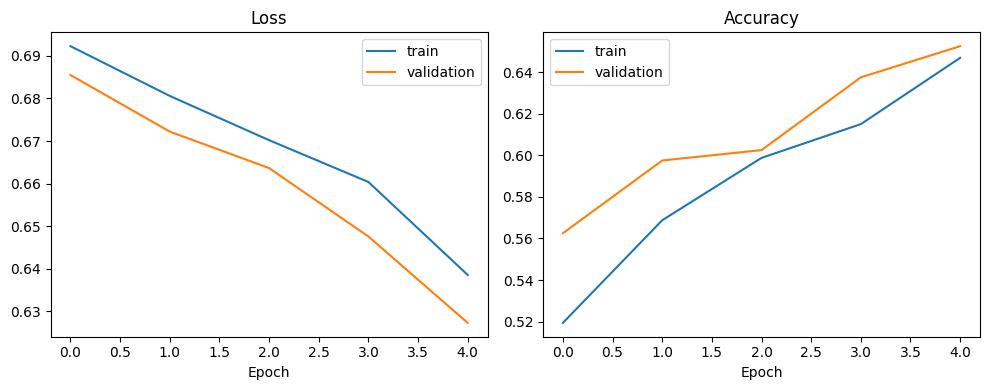

Test accuracy: 0.656


In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

test_loss, test_accuracy = classifier.evaluate(test_ds, verbose=0)
print(f'Test accuracy: {test_accuracy:.3f}')

In [11]:
reviews = [
    'The movie was moving and beautifully acted.',
    'The film was boring, confusing, and far too long.'
]
probabilities = classifier.predict(reviews, verbose=0)
for review, probability in zip(reviews, probabilities):
    label = 'positive' if np.argmax(probability) == 1 else 'negative'
    print(review)
    print('Probabilities:', np.round(probability, 3), 'Prediction:', label, '\n')

The movie was moving and beautifully acted.
Probabilities: [0.466 0.534] Prediction: positive 

The film was boring, confusing, and far too long.
Probabilities: [0.544 0.456] Prediction: negative 



# Part D — Practical 2: System/User/Assistant Generation with int8 QLoRA

This uses a very small teaching dataset. It demonstrates the pipeline, not production-quality instruction tuning.

In [12]:
instruction_examples = [
    {'system': 'You are a concise educational assistant.', 'user': 'What is machine learning?', 'assistant': 'Machine learning learns patterns from data to make predictions or decisions.'},
    {'system': 'You are a concise educational assistant.', 'user': 'What is overfitting?', 'assistant': 'Overfitting occurs when a model memorizes training details and performs poorly on unseen data.'},
    {'system': 'You are a concise educational assistant.', 'user': 'Explain gradient descent.', 'assistant': 'Gradient descent repeatedly updates parameters in the direction that reduces loss.'},
    {'system': 'You are a concise educational assistant.', 'user': 'What is an epoch?', 'assistant': 'An epoch is one complete pass through the training dataset.'},
    {'system': 'You are a concise educational assistant.', 'user': 'What is LoRA?', 'assistant': 'LoRA freezes the base model and trains small low-rank matrices in selected layers.'},
    {'system': 'You are a concise educational assistant.', 'user': 'Why use validation data?', 'assistant': 'Validation data helps select settings and detect overfitting without using the final test set.'}
]

def format_conversation(example, include_assistant=True):
    text = f"System: {example['system']}\nUser: {example['user']}\nAssistant:"
    if include_assistant:
        text += f" {example['assistant']}"
    return text

formatted_examples = [format_conversation(x) for x in instruction_examples]
print(formatted_examples[0])

System: You are a concise educational assistant.
User: What is machine learning?
Assistant: Machine learning learns patterns from data to make predictions or decisions.


## 1. Load GPT-2, quantize, then enable LoRA

The order is essential: load → quantize frozen base → enable trainable LoRA.

In [14]:
gpt2_preset = "gpt2_base_en"

gpt2_preprocessor = (
    keras_hub.models.GPT2CausalLMPreprocessor.from_preset(
        gpt2_preset,
        sequence_length=128
    )
)

gpt2_lm = keras_hub.models.GPT2CausalLM.from_preset(
    gpt2_preset,
    preprocessor=gpt2_preprocessor
)

# Quantize only compatible Dense/EinsumDense layers.
# This avoids the ReversibleEmbedding compatibility error.
quantized_layers = 0

for layer in gpt2_lm.backbone._flatten_layers():
    if isinstance(
        layer,
        (keras.layers.Dense, keras.layers.EinsumDense)
    ):
        try:
            layer.quantize("int8")
            quantized_layers += 1
        except (ValueError, TypeError, NotImplementedError):
            # Skip layers that do not support int8 quantization
            pass

print("Quantized layers:", quantized_layers)

# Add trainable LoRA matrices after quantizing the base layers
gpt2_lm.backbone.enable_lora(rank=4)

gpt2_lm.summary()

trainable = sum(
    np.prod(weight.shape)
    for weight in gpt2_lm.trainable_weights
)

total = sum(
    np.prod(weight.shape)
    for weight in gpt2_lm.weights
)

print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print(f"Trainable percentage: {100 * trainable / total:.3f}%")

Quantized layers: 72


Preprocessor: "gpt2_causal_lm_preprocessor_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gpt2_tokenizer (GPT2Tokenizer)                                │                       Vocab size: 50,257 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gpt2_causal_lm_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gpt2_backbone (GPT2Backbone)  │ (None, None, 768)         │     125,413,632 │ padding_mask[0][0],        │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 50257)       │      38,597,376 │ gpt2_backbone[0][0]        │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 125,413,632 (235.42 MB)

 Trainable params: 909,312 (3.47 MB)

 Non-trainable params: 124,504,320 (231.95 MB)

Trainable parameters: 909,312
Total parameters: 125,413,632
Trainable percentage: 0.725%


## 2. Create TensorFlow data and fine-tune

In [15]:
instruction_ds = (
    tf.data.Dataset.from_tensor_slices(formatted_examples)
    .repeat(10)
    .shuffle(60, seed=42)
    .batch(2)
    .prefetch(tf.data.AUTOTUNE)
)

gpt2_lm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy(name='token_accuracy')]
)
gpt2_history = gpt2_lm.fit(instruction_ds, epochs=1)

30/30 ━━━━━━━━━━━━━━━━━━━━ 58s 70ms/step - loss: 1.4812 - token_accuracy: 0.2826


## 3. Generate a response

In [18]:
test_example = {
    "system": "You are a concise educational assistant.",
    "user": "What is LoRA?",
    "assistant": ""
}

prompt = format_conversation(
    test_example,
    include_assistant=False
)

gpt2_lm.compile(sampler="greedy")

completion = gpt2_lm.generate(
    prompt,
    max_length=70,
    stop_token_ids="auto",
    strip_prompt=True
)

# Remove an accidentally generated next conversation
completion = completion.split("System:")[0]
completion = completion.split("User:")[0]
completion = completion.strip()

print("Assistant:", completion)

Assistant: LoRA is a simple, yet powerful, program that allows you to create a simple, yet powerful, program that will teach you how to create a simple, yet powerful, program.


## Final comparison

| Aspect | Practical 1 | Practical 2 |
|---|---|---|
| Objective | Classification SFT | Conversational generative SFT |
| Model | BERT | GPT-2 |
| Output | Sentiment class | Assistant text |
| Base precision | Standard preset precision | Int8 quantized |
| PEFT | LoRA | QLoRA |
| Main API | `predict()` | `generate()` |

## Colab troubleshooting

- Always start with a fresh GPU runtime and run cells in order.
- Do not import Keras before the installation cell.
- If Colab explicitly asks for a runtime restart after installation, restart and continue from the import cell.
- If GPU memory is insufficient, reduce GPT-2 sequence length to 64.
- The first generation call can be slow because Keras compiles the generation graph.
- Internet access is required to download the datasets and pretrained presets.